<a href="https://colab.research.google.com/github/HemenDishri/IITM/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

#data = pd.read_csv("train.csv")
#test = pd.read_csv("test.csv")

card_data= pd.read_csv("card_transdata.csv")

In [5]:
card_data = pd.get_dummies(card_data, columns=['repeat_retailer', 'used_chip', 'used_pin_number', 'online_order'], drop_first=False)
card_data

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,fraud,repeat_retailer_N,repeat_retailer_Y,used_chip_N,used_chip_Y,used_pin_number_N,used_pin_number_Y,online_order_N,online_order_Y
0,57.877857,0.311140,1.945940,0,False,True,False,True,True,False,True,False
1,10.829943,0.175592,1.294219,0,False,True,True,False,True,False,True,False
2,5.091079,0.805153,0.427715,0,False,True,True,False,True,False,False,True
3,2.247564,5.600044,0.362663,0,False,True,False,True,True,False,False,True
4,44.190936,0.566486,2.222767,0,False,True,False,True,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2.207101,0.112651,1.626798,0,False,True,False,True,True,False,True,False
999996,19.872726,2.683904,2.778303,0,False,True,False,True,True,False,True,False
999997,2.914857,1.472687,0.218075,0,False,True,False,True,True,False,False,True
999998,4.258729,0.242023,0.475822,0,False,True,True,False,True,False,False,True


In [6]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = card_data.drop(columns=['fraud'])  # Features
y = card_data['fraud']  # Labels

# Split the data into train and test samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800000, 11), (200000, 11), (800000,), (200000,))

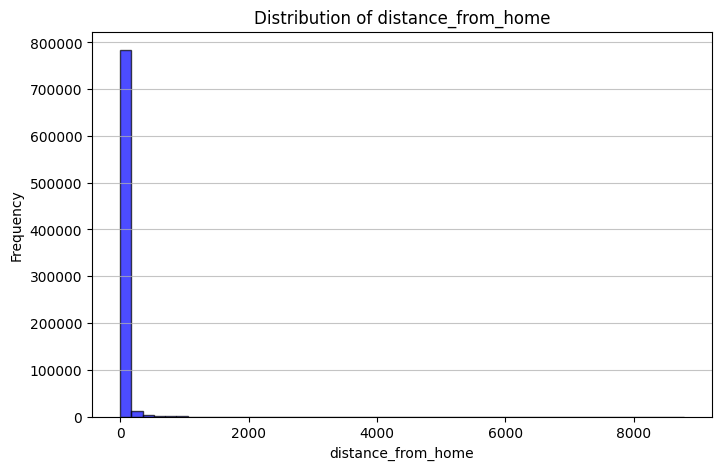

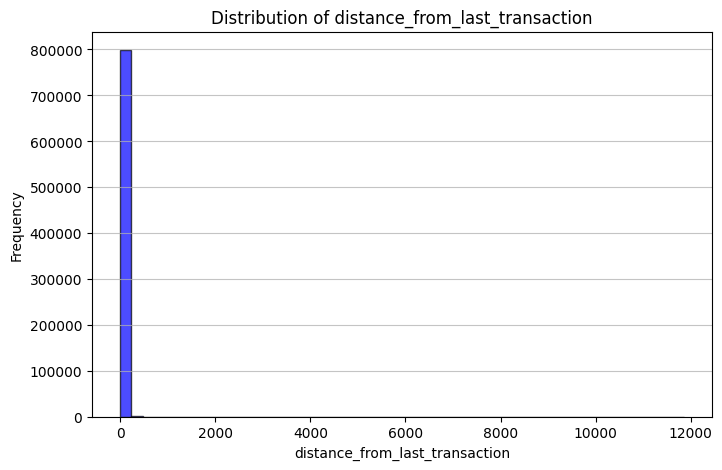

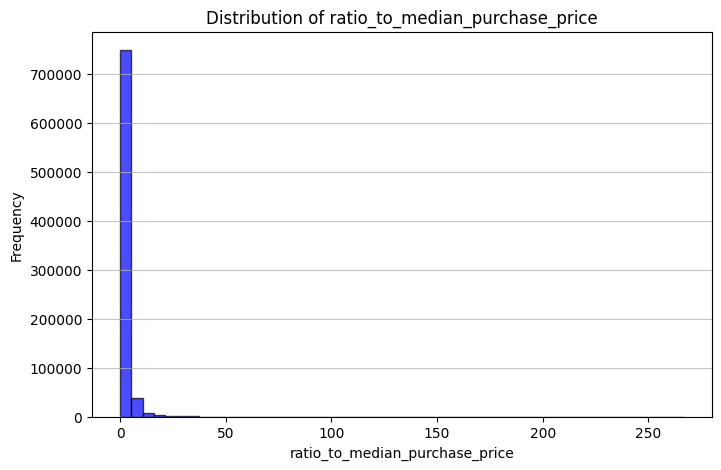

In [7]:
import matplotlib.pyplot as plt

# List of numerical columns
numerical_columns = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

# Plot histograms for each numerical column
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(X_train[column], bins=50, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

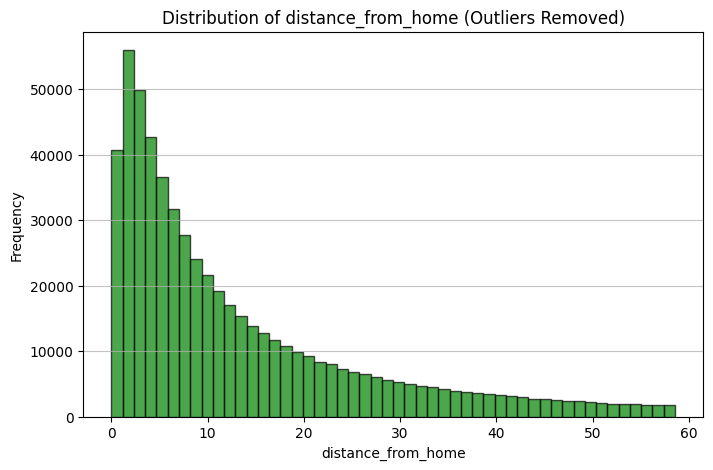

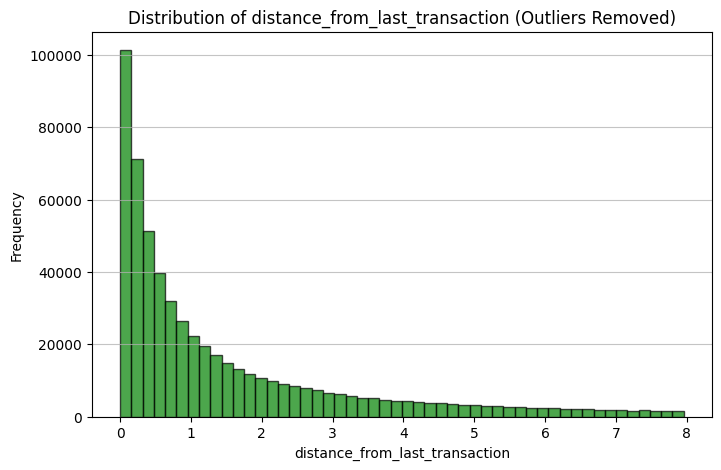

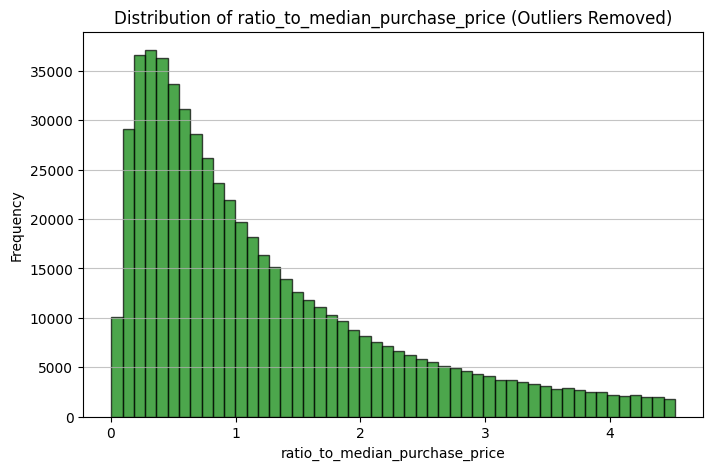

In [12]:
# Define a function to remove outliers using the IQR method
def remove_outliers(df, columns):
    for column in columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df

# Remove outliers from the training data
X_train_cleaned = remove_outliers(X_train.copy(), numerical_columns)
X_test_cleaned = remove_outliers(X_test.copy(), numerical_columns)

# Plot histograms for each numerical column after removing outliers
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(X_train_cleaned[column], bins=50, color='green', alpha=0.7, edgecolor='black')
    plt.title(f'Distribution of {column} (Outliers Removed)')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

In [8]:
# prompt: # Create 4 nonlinear predictors as combinations of the existing features from card_data

# Create 4 nonlinear predictors as combinations of the existing features
import numpy as np
X_train['distance_ratio'] = X_train['distance_from_home'] / (X_train['distance_from_last_transaction'] + 1e-5)
X_train['distance_product'] = X_train['distance_from_home'] * X_train['distance_from_last_transaction']
X_train['log_ratio_to_median'] = np.log1p(X_train['ratio_to_median_purchase_price'])
X_train['sqrt_distance_from_home'] = np.sqrt(X_train['distance_from_home'])

X_train

X_test = X_test.copy()
X_test['distance_ratio'] = X_test['distance_from_home'] / (X_test['distance_from_last_transaction'] + 1e-5)
X_test['distance_product'] = X_test['distance_from_home'] * X_test['distance_from_last_transaction']
X_test['log_ratio_to_median'] = np.log1p(X_test['ratio_to_median_purchase_price'])
X_test['sqrt_distance_from_home'] = np.sqrt(X_test['distance_from_home'])

X_test

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer_N,repeat_retailer_Y,used_chip_N,used_chip_Y,used_pin_number_N,used_pin_number_Y,online_order_N,online_order_Y,distance_ratio,distance_product,log_ratio_to_median,sqrt_distance_from_home
987231,0.929509,1.296477,0.361110,True,False,True,False,True,False,False,True,0.716945,1.205087,0.308301,0.964111
79954,0.611179,0.208295,3.118884,True,False,True,False,True,False,False,True,2.934064,0.127305,1.415582,0.781779
567130,3.956062,0.529194,1.579942,False,True,True,False,True,False,True,False,7.475499,2.093523,0.947767,1.988985
500891,21.798902,0.019399,11.416909,False,True,True,False,True,False,True,False,1123.116351,0.422883,2.519059,4.668929
55399,3.310635,1.707802,2.028915,False,True,True,False,True,False,True,False,1.938524,5.653908,1.108204,1.819515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90245,56.686649,0.820179,6.051695,False,True,True,False,False,True,False,True,69.114147,46.493187,1.953268,7.529054
639296,5.544863,0.072644,1.350344,False,True,True,False,True,False,False,True,76.318239,0.402804,0.854562,2.354753
311939,4.449740,2.045690,9.814511,False,True,False,True,True,False,False,True,2.175167,9.102791,2.380889,2.109441
324459,34.624330,0.580115,0.424248,False,True,True,False,True,False,True,False,59.684270,20.086089,0.353644,5.884244


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Define the pipeline with standardization and logistic regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='saga', max_iter=10000))
])

# Define the parameter grid for lambda (C is the inverse of regularization strength)
param_grid = {
    'logistic__C': [ 0.1, 1, 10, 100]
}

# Perform GridSearchCV to find the best lambda with a reduced dataset to avoid long runtime
# Reduce the size of the training data for faster computation
X_train_sampled = X_train.sample(frac=0.1, random_state=42)
y_train_sampled = y_train.loc[X_train_sampled.index]  # Corrected to use y_train instead of y_train_cleaned

# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_sampled, y_train_sampled)

# Best parameters and score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score

({'logistic__C': 0.1}, np.float64(0.956825))

In [15]:
# prompt: tun the regression results on test data and generate the classification report

# Use the best found parameters to train the model on the full training data
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(penalty='l1', solver='saga', max_iter=10000, C=best_params['logistic__C']))
])

best_pipeline.fit(X_train, y_train)

# Predict on the test data
y_pred = best_pipeline.predict(X_test)

# Generate and print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    182557
           1       0.82      0.65      0.73     17443

    accuracy                           0.96    200000
   macro avg       0.89      0.82      0.85    200000
weighted avg       0.95      0.96      0.95    200000



Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20000/20000 ━━━━━━━━━━━━━━━━━━━━ 53s 3ms/step - accuracy: 0.9893 - loss: 0.0299 - val_accuracy: 0.9966 - val_loss: 0.0090
Epoch 2/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 78s 2ms/step - accuracy: 0.9963 - loss: 0.0091 - val_accuracy: 0.9979 - val_loss: 0.0066
Epoch 3/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 80s 2ms/step - accuracy: 0.9970 - loss: 0.0081 - val_accuracy: 0.9977 - val_loss: 0.0058
Epoch 4/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9973 - loss: 0.0068 - val_accuracy: 0.9976 - val_loss: 0.0064
Epoch 5/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.9974 - loss: 0.0068 - val_accuracy: 0.9981 - val_loss: 0.0045
Epoch 6/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9977 - loss: 0.0061 - val_accuracy: 0.9986 - val_loss: 0.0037
Epoch 7/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 75s 2ms/step - accuracy: 0.9978 - loss: 0.0056 - val_accuracy: 0.9975 - val_loss: 0.0055
Epoch 8/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 85s 3ms/step - accuracy: 0.9979 - lo

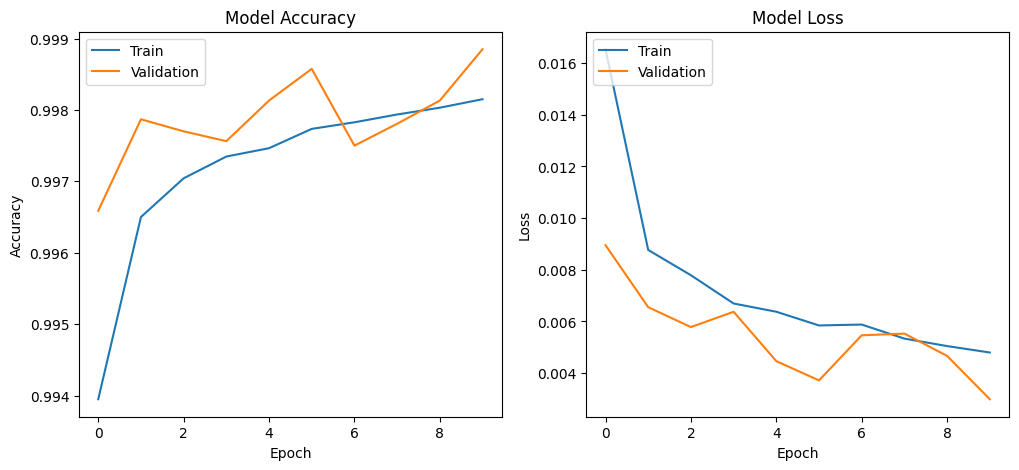

In [18]:
# prompt: standardize and Fit a simple Neural Network model with only 2 hidden layer using ReLU

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Assuming X_train and X_test are already defined and preprocessed as in the preceding code
# You might need to ensure the features created previously (distance_ratio, etc.) are included
# and that outliers were handled if desired.

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
# You might adjust epochs and batch_size based on your dataset size and performance
history = model.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# Optional: Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [19]:
# prompt: Generate and print the classification report

# Assuming y_test and y_pred are already calculated from the trained model

# Generate and print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    182557
           1       0.82      0.65      0.73     17443

    accuracy                           0.96    200000
   macro avg       0.89      0.82      0.85    200000
weighted avg       0.95      0.96      0.95    200000



Epoch 1/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - accuracy: 0.9122 - loss: 0.9398 - val_accuracy: 0.9126 - val_loss: 0.3371
Epoch 2/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.9126 - loss: 0.3374 - val_accuracy: 0.9126 - val_loss: 0.3369
Epoch 3/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 83s 3ms/step - accuracy: 0.9127 - loss: 0.3370 - val_accuracy: 0.9126 - val_loss: 0.3370
Epoch 4/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9128 - loss: 0.3367 - val_accuracy: 0.9126 - val_loss: 0.3375
Epoch 5/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - accuracy: 0.9128 - loss: 0.3368 - val_accuracy: 0.9126 - val_loss: 0.3375
Epoch 6/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 64s 3ms/step - accuracy: 0.9130 - loss: 0.3360 - val_accuracy: 0.9126 - val_loss: 0.3368
Epoch 7/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 84s 3ms/step - accuracy: 0.9122 - loss: 0.3380 - val_accuracy: 0.9126 - val_loss: 0.3367
Epoch 8/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 79s 3ms/step - accuracy: 

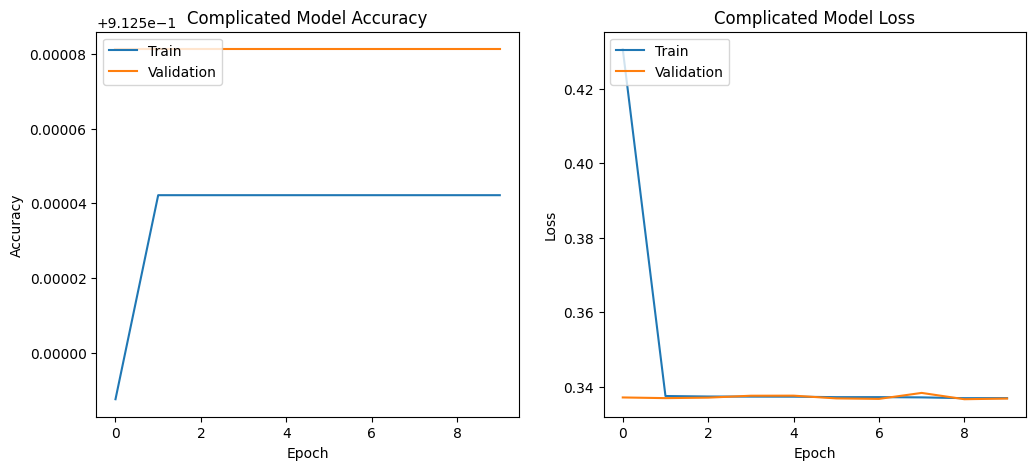

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       0.91      1.00      0.95    182557
           1       0.00      0.00      0.00     17443

    accuracy                           0.91    200000
   macro avg       0.46      0.50      0.48    200000
weighted avg       0.83      0.91      0.87    200000



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
# prompt: Fit a more complicated Neural Network by increasing the layer to 5 and number of neurons by 10 % and add an L1 penalization inside each layer.

# Build the more complicated neural network model
# Calculate the new number of neurons: original * 1.10
original_neurons = 128 # Assuming the previous model's first layer had 128 neurons
new_neurons = int(original_neurons * 1.10) # Apply the 10% increase

model_complicated = Sequential([
    Dense(new_neurons, activation='relu', input_shape=(X_train_scaled.shape[1],),
          kernel_regularizer=tf.keras.regularizers.l1(0.01)), # L1 regularization
    Dense(int(new_neurons * 0.8), activation='relu', # Example of decreasing neurons in subsequent layers
          kernel_regularizer=tf.keras.regularizers.l1(0.01)), # L1 regularization
    Dense(int(new_neurons * 0.6), activation='relu',
          kernel_regularizer=tf.keras.regularizers.l1(0.01)), # L1 regularization
    Dense(int(new_neurons * 0.4), activation='relu',
          kernel_regularizer=tf.keras.regularizers.l1(0.01)), # L1 regularization
    Dense(int(new_neurons * 0.2), activation='relu',
          kernel_regularizer=tf.keras.regularizers.l1(0.01)), # L1 regularization
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model_complicated.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
# You might adjust epochs and batch_size based on your dataset size and performance
history_complicated = model_complicated.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss_complicated, accuracy_complicated = model_complicated.evaluate(X_test_scaled, y_test)
print(f'Complicated Model Test Loss: {loss_complicated:.4f}')
print(f'Complicated Model Test Accuracy: {accuracy_complicated:.4f}')

# Optional: Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_complicated.history['accuracy'])
plt.plot(history_complicated.history['val_accuracy'])
plt.title('Complicated Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_complicated.history['loss'])
plt.plot(history_complicated.history['val_loss'])
plt.title('Complicated Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Predict on the test data using the complicated model
y_pred_complicated = (model_complicated.predict(X_test_scaled) > 0.5).astype("int32")

# Generate and print the classification report for the complicated model
print(classification_report(y_test, y_pred_complicated))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - accuracy: 0.9865 - loss: 0.0379 - val_accuracy: 0.9960 - val_loss: 0.0106
Epoch 2/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9952 - loss: 0.0127 - val_accuracy: 0.9968 - val_loss: 0.0083
Epoch 3/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.9960 - loss: 0.0110 - val_accuracy: 0.9971 - val_loss: 0.0069
Epoch 4/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 52s 3ms/step - accuracy: 0.9965 - loss: 0.0098 - val_accuracy: 0.9976 - val_loss: 0.0064
Epoch 5/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9967 - loss: 0.0089 - val_accuracy: 0.9968 - val_loss: 0.0080
Epoch 6/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9967 - loss: 0.0090 - val_accuracy: 0.9985 - val_loss: 0.0041
Epoch 7/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9970 - loss: 0.0095 - val_accuracy: 0.9985 - val_loss: 0.0042
Epoch 8/10
20000/20000 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 

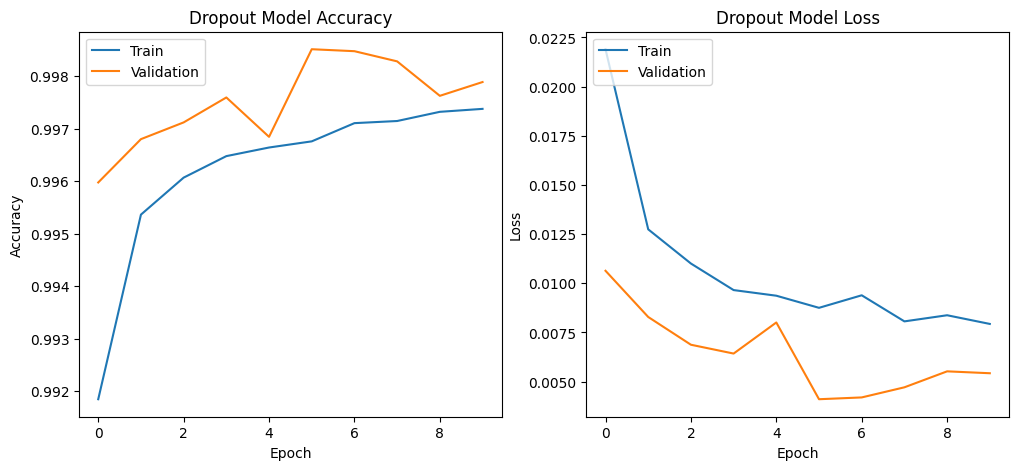

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    182557
           1       0.99      0.99      0.99     17443

    accuracy                           1.00    200000
   macro avg       0.99      0.99      0.99    200000
weighted avg       1.00      1.00      1.00    200000



In [22]:
# prompt: Take the Neural NEtwork, and instead of adding the L1 Penalization add 2 Droput layers

from tensorflow.keras.layers import Dropout

# Build the neural network model with Dropout layers
model_dropout = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Add first Dropout layer
    Dense(64, activation='relu'),
    Dropout(0.2), # Add second Dropout layer
    Dense(1, activation='sigmoid') # Output layer for binary classification
])

# Compile the model
model_dropout.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# Train the model
# You might adjust epochs and batch_size based on your dataset size and performance
history_dropout = model_dropout.fit(X_train_scaled, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model on the test set
loss_dropout, accuracy_dropout = model_dropout.evaluate(X_test_scaled, y_test)
print(f'Dropout Model Test Loss: {loss_dropout:.4f}')
print(f'Dropout Model Test Accuracy: {accuracy_dropout:.4f}')

# Optional: Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dropout.history['accuracy'])
plt.plot(history_dropout.history['val_accuracy'])
plt.title('Dropout Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history_dropout.history['loss'])
plt.plot(history_dropout.history['val_loss'])
plt.title('Dropout Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Predict on the test data using the dropout model
y_pred_dropout = (model_dropout.predict(X_test_scaled) > 0.5).astype("int32")

# Generate and print the classification report for the dropout model
print(classification_report(y_test, y_pred_dropout))